In [1]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function
from poi.probes import create_sinc_probe

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle
from tqdm import tqdm

# Generate Pairwise Probe Commands

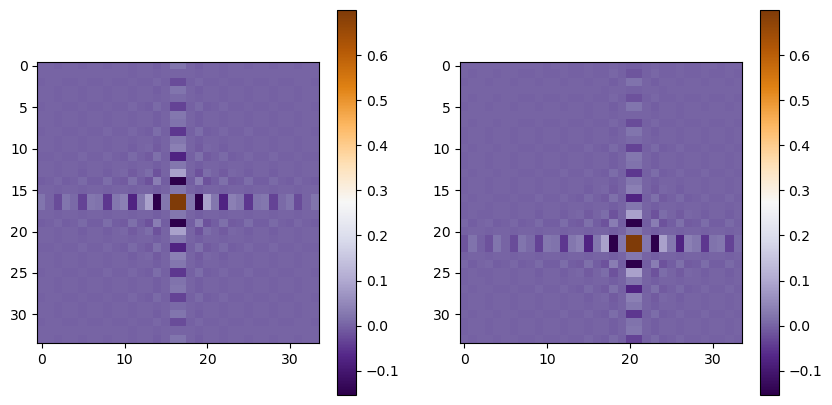

In [2]:
Nacts = 34
amp = 1
probe_radius = 11 # is this L/D ?
shift = (4, 5)

probe1 = create_sinc_probe(Nacts=Nacts,
                          amp=amp,
                          probe_radius=probe_radius)

probe2 = create_sinc_probe(Nacts=Nacts,
                          amp=amp,
                          probe_radius=probe_radius,
                          offset=shift)

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.imshow(probe1, cmap="PuOr_r")
plt.colorbar()
plt.subplot(122)
plt.imshow(probe2, cmap="PuOr_r")
plt.colorbar()
plt.show()

# Set up a PSD wavefront error

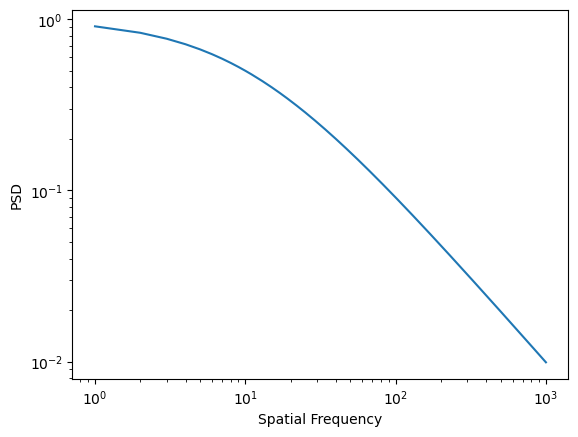

In [3]:
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=1, b=10, c=1)

plt.figure()
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.show()


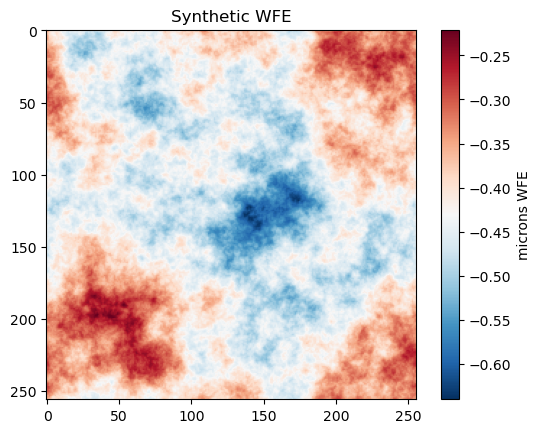

In [4]:
# Just picked ABC values until it looked about right
Npup = 256
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

plt.figure()
plt.title('Synthetic WFE')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.show()

# 2. Set up a diffraction model

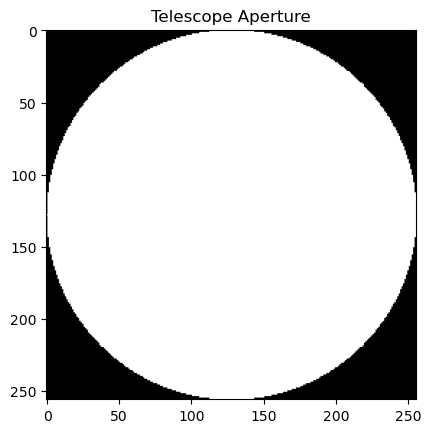

In [5]:
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)
A = circle(1, r)
plt.figure()
plt.imshow(A, cmap='gray')
plt.title('Telescope Aperture')
plt.show()

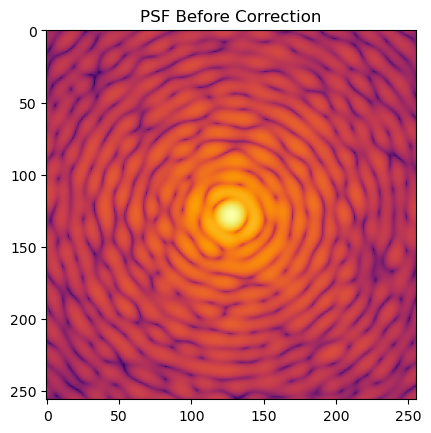

In [6]:
# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL * z) # with error

focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

focal_intensity = np.abs(focal)**2

plt.title('PSF Before Correction')
plt.imshow(focal_intensity, cmap='inferno', norm=LogNorm())

# Now in principle, I think iEFC works in direct-imaging mode

0.1


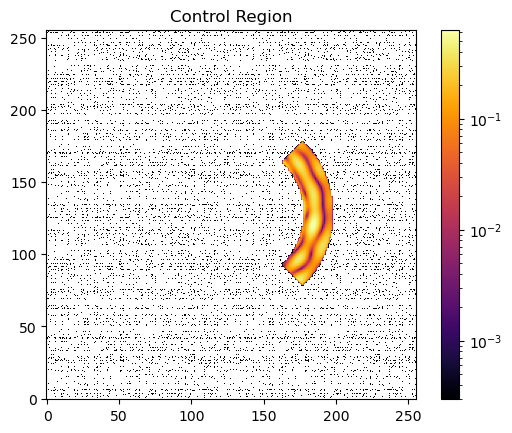

In [7]:
# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
print(um_to_LD)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
IWA = 5
OWA = 7
dark_hole[rho < 7] = 1
dark_hole[rho < 5] = 0
dark_hole[psi > np.pi / 4] = 0
dark_hole[psi < -np.pi / 4] = 0
# dark_hole[u < 5] = 0


masked_intensity = dark_hole * focal_intensity
plt.title('Control Region')
plt.imshow(masked_intensity, cmap='inferno', norm=LogNorm(), origin='lower')

plt.colorbar()

# Configure Deformable Mirror with Modes

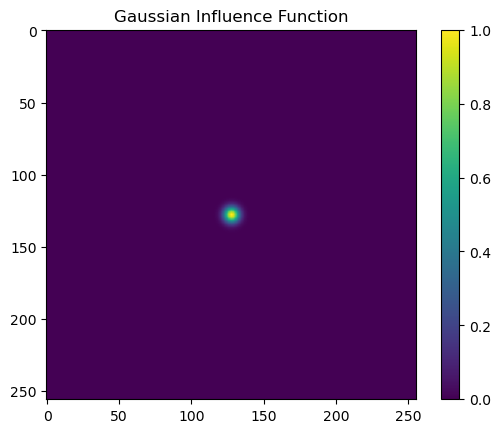

In [8]:
# Set up DM
nact = 34 # number of actuators
act_pitch = 1 # mm?
samples_per_act = 7 # chosen to over-fill illuminated aperture
sampling_pitch = act_pitch / samples_per_act

xdm, ydm = make_xy_grid(Npup, dx=sampling_pitch)
rhodm, _ = cart_to_polar(xdm, ydm)
influence_func = gaussian_influence_function(rho, sampling_pitch)

plt.title("Gaussian Influence Function")
plt.imshow(influence_func)
plt.colorbar()
plt.show()

In [9]:
dm = DM(influence_func, Nout=Npup, Nact=nact, sep=samples_per_act)

# Generate a random modal basis

In [10]:
from poi.modes import hadamard_modes_sequence

xact, yact = make_xy_grid(nact, dx=act_pitch)
rhoact, thact = cart_to_polar(xact, yact)
circ_dm_mask = np.ones_like(xact)

def poke_mode_sequence(mask, amplitude=1.):

    modes = []
    zero_mask = np.zeros_like(mask)

    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):

            # poke
            poke_mode = np.copy(zero_mask)
            poke_mode[i, j] = amplitude
            modes.append(poke_mode)

    return modes

modes = poke_mode_sequence(circ_dm_mask)
# modes = hadamard_modes_sequence(circ_dm_mask) / 100
# print(f"Num Modes = {modes.shape[0]}")

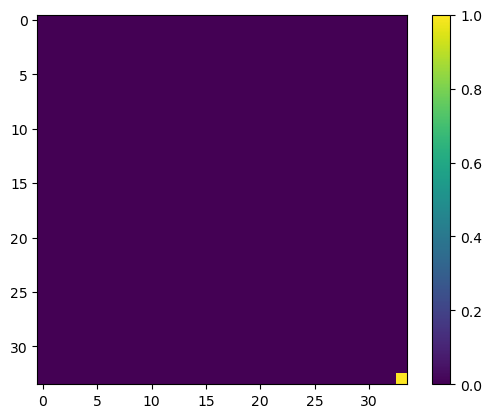

In [11]:
plt.imshow(modes[-1])
plt.colorbar()

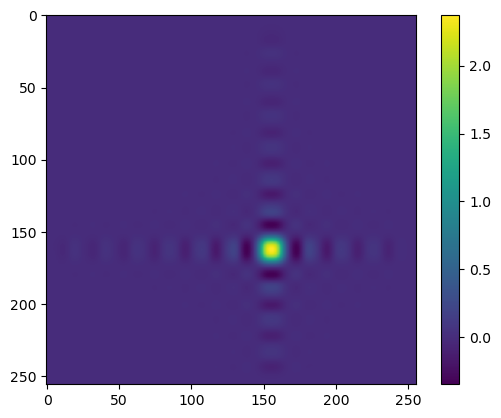

In [12]:
dm.actuators[:] = probe2 #modes[-1]
plt.imshow(dm.render() * A)
plt.colorbar()

In [13]:
def fwd(pupil_wfe=np.ones_like(wvfnt)):
    focal = focus_fixed_sampling(wvfnt * pupil_wfe,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    return focal

In [42]:
def tikhonov_inverse(A, rcond=1e-3):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    s_inv = s/(s**2 + (rcond * s.max())**2)
    return (Vt.T * s_inv).dot(U.T)

def beta_reg(J, beta=-2):
    # J is the Jacobian
    JTJ = np.matmul(J.T, J)
    rho = np.diag(JTJ)
    alpha2 = rho.max()

    control_matrix = np.matmul( np.linalg.inv( JTJ + alpha2*10.0**(beta) * np.eye(JTJ.shape[0]) ), J.T)
    return control_matrix

class iEFC:

    def __init__(self, propagation, dm, modes, probes, dh, probe_amplitude=1., mode_amplitude=1., wavelength=1):

        self.fwd = propagation
        self.dm = dm
        self.modes = modes
        self.probes = probes
        self.dh = dh
        self.probe_amplitude = probe_amplitude
        self.mode_amplitude = mode_amplitude
        self.kvec = 2 * np.pi / wavelength
        self.images = []
        self.mean_in_dh = []

    def measurement(self):

        difference_images = []

        for i, probe in enumerate(self.probes):

            # apply the positive mode
            self.dm.actuators[:] += probe * self.probe_amplitude
            im_pos = np.abs(fwd(np.exp(1j * dm.render(wfe=True))))**2

            # remove surface
            self.dm.actuators[:] -= probe * self.probe_amplitude

            # apply the negative mode
            self.dm.actuators[:] += -1 * probe * self.probe_amplitude
            im_neg = np.abs(fwd(np.exp(1j * dm.render(wfe=True))))**2

            # remove the surface
            self.dm.actuators[:] -= -1 * probe * self.probe_amplitude

            diff_img = (im_pos - im_neg) / (2 * self.probe_amplitude)
            difference_images.append(diff_img)

        return np.asarray(difference_images)


    def calibrate(self):

        response_matrix = []
        calibration_amplitudes = []

        N_probes = len(self.modes)
        N_img_sq = self.dh.size

        for i, calibration_mode in tqdm(enumerate(modes)):
            
            # Loading the response matrix
            response = 0

            for s in [-1, 1]:

                # apply to DM
                self.dm.actuators[:] += s * self.mode_amplitude * calibration_mode
                diff_ims = self.measurement()
                response += s * diff_ims / (2 * self.mode_amplitude)

                # remove from DM
                self.dm.actuators[:] -= s * self.mode_amplitude * calibration_mode

            if len(self.probes) == 2:
                response_matrix.append(np.concatenate([
                    response[0, self.dh==1],
                    response[1, self.dh==1]
                ]))

            else:
                raise NotImplementedError
            
        self.response_matrix = np.array(response_matrix).T

    def compute_control_matrix(self):
        # self.control_matrix = np.linalg.pinv(self.response_matrix)
        # self.control_matrix = tikhonov_inverse(self.response_matrix)
        self.control_matrix = beta_reg(self.response_matrix)

    def step(self, loop_gain=1., leakage=0., update_probe_amplitude=None):

        if not hasattr(self, "control_matrix"):
            self.compute_control_matrix()

        if not hasattr(self, "total_command"):
            self.total_command = np.zeros(self.dm.Nact)

        if update_probe_amplitude is not None:
            self.probe_amplitude = update_probe_amplitude

        diff_ims = self.measurement()
        measurement_vector = diff_ims[:, self.dh==1].ravel()
        modal_matrix = np.asarray(self.modes).reshape(len(self.modes), -1)

        modal_coeff = -self.control_matrix.dot(measurement_vector)
        del_command = modal_matrix.T.dot(modal_coeff).reshape(self.dm.Nact)
        self.total_command = (1 - leakage) * self.total_command + loop_gain * del_command

        self.dm.actuators[:] += self.total_command

        # take an image
        img = np.abs(self.fwd(np.exp(1j * self.dm.render(wfe=True))))**2
        self.images.append(img)
        self.mean_in_dh.append(np.mean(img[self.dh==1]))

        return img

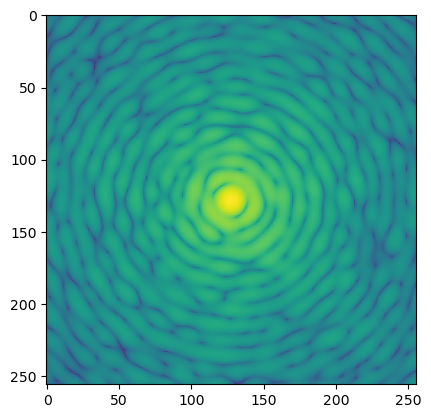

In [43]:
dm.actuators[:] = modes[-1]
wfe = np.exp(1j * 2 * np.pi * dm.render(wfe=True))
psf = np.abs(fwd(wfe))**2
plt.imshow(psf, norm=LogNorm())

In [44]:
iefc = iEFC(fwd, dm, modes, [probe1, probe2], dark_hole,
            probe_amplitude=1e-1, # radians
            mode_amplitude=1e0)

In [45]:
iefc.calibrate()

1156it [00:56, 20.37it/s]


In [46]:
iefc.compute_control_matrix()

In [47]:
iefc.response_matrix.shape

(3796, 1156)

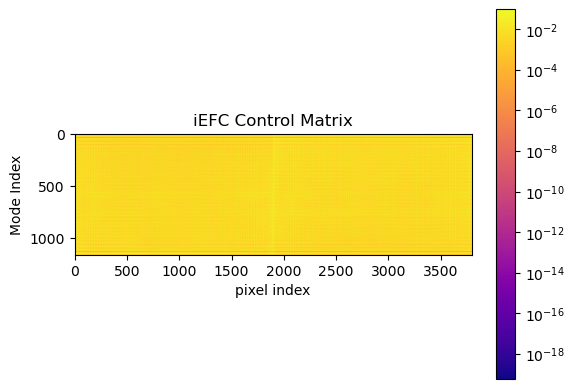

In [48]:
plt.title("iEFC Control Matrix")
plt.imshow(np.abs(iefc.control_matrix), cmap="plasma", norm=LogNorm())
plt.ylabel("Mode Index")
plt.xlabel("pixel index")
plt.colorbar()

In [49]:
# try step forward
for i in range(10):
    iefc.step()

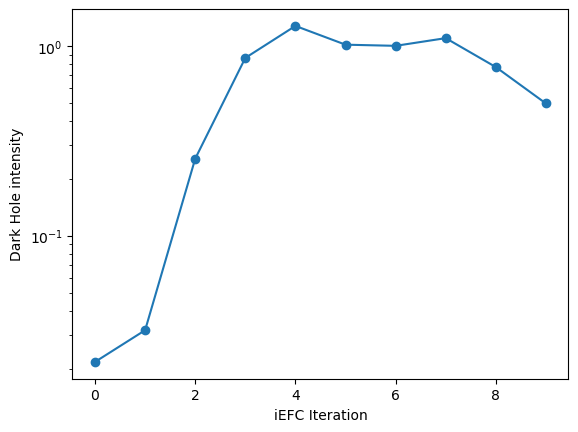

In [50]:
plt.plot(iefc.mean_in_dh, marker='o')
plt.ylabel("Dark Hole intensity")
plt.xlabel("iEFC Iteration")
plt.yscale("log")

([], [])

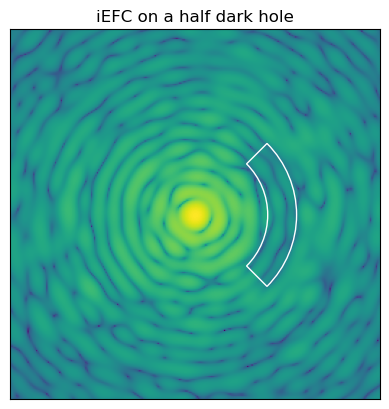

In [53]:
from matplotlib.patches import Wedge
plt.imshow(np.log10(iefc.images[0]))
plt.title("iEFC on a half dark hole")
ax = plt.gca()

# set up dark hole
scale = Dpup / dx_img / WVL
dh_region = Wedge((128, 128), r= OWA * scale, width=(OWA - IWA) * scale,
                  theta1=-45, theta2=45, facecolor="None", edgecolor="w")
ax.add_patch(dh_region)
plt.xticks([],[])
plt.yticks([],[])

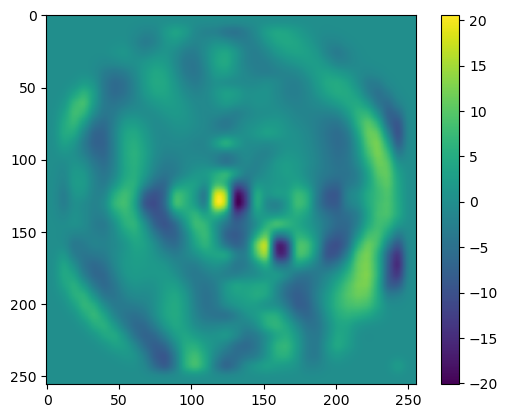

In [52]:
plt.imshow(dm.render())
plt.colorbar()
plt.show()